# Notebook 03 — Análisis Exploratorio de Datos (EDA)
**Proyecto Integrador | Minería de Datos I**

## Objetivo
Explorar el dataset limpio para descubrir patrones, distribuciones y relaciones entre variables que permitan generar hipótesis y orientar el análisis posterior.

## Etapa
Esta es la etapa 3 de 5. Se trabaja sobre `data/processed/streaming_users_clean.csv`.

In [23]:
# Cargo el dataset limpio
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/processed/streaming_users_clean.csv')

print(f"Dimensiones: {df.shape[0]} filas y {df.shape[1]} columnas.")
df.head()

Dimensiones: 8000 filas y 8 columnas.


,user_id,age,subscription_plan,monthly_watch_time_mins,country,favorite_genre,last_login_date,customer_support_tickets
0,10000,39,Estándar,805.8,Brasil,Crimen,2025-03-04,0
1,10001,37,Estándar,1173.4,Colombia,Crimen,2019-04-02,2
2,10002,28,Básico,401.0,Colombia,Crimen,2018-04-13,0
3,10003,43,Básico,62.4,Uruguay,Thriller,2021-01-31,0
4,10004,51,Básico,477.8,Perú,Thriller,2020-09-30,1


## Análisis Univariado
Exploración individual de cada variable para comprender su distribución y detectar patrones generales.

In [24]:
print(f"Media: {df['age'].mean():.2f}")
print(f"Mediana: {df['age'].median():.2f}")
print(f"Moda: {df['age'].mode()[0]:.2f}")
print(f"Desvío estándar: {df['age'].std():.2f}")
print(f"Mínimo: {df['age'].min():.2f}")
print(f"Máximo: {df['age'].max():.2f}")

Media: 35.59
Mediana: 35.00
Moda: 35.00
Desvío estándar: 9.68
Mínimo: 18.00
Máximo: 80.00


**Medidas de age:** La media (35.59), la mediana (35.00) y la moda (35.00) son prácticamente idénticas, lo que indica una distribución muy simétrica. El desvío estándar de 9.68 indica una dispersión moderada alrededor de la media. El rango va de 18 a 80 años, consistente con el criterio aplicado en la limpieza de excluir menores de edad.

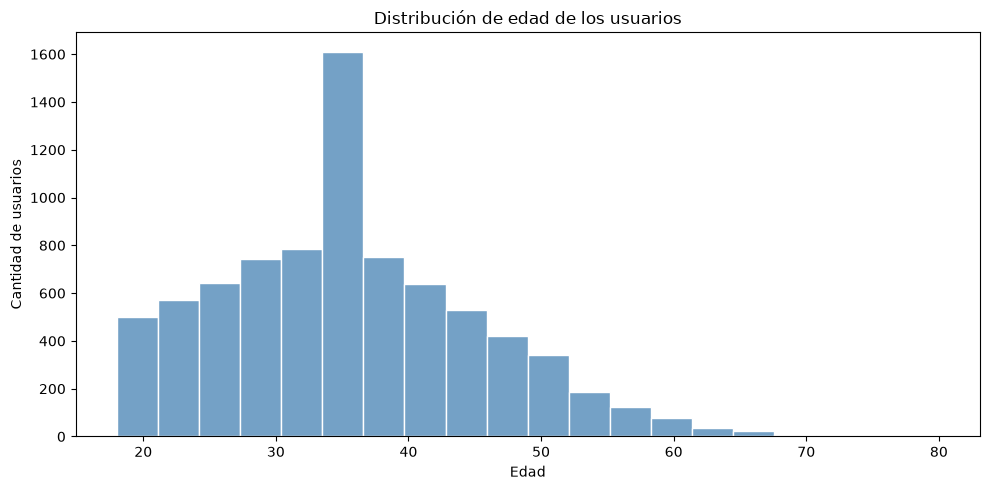

In [25]:
# Distribución de edad (age)
plt.figure(figsize=(10, 5))
sns.histplot(df['age'], bins=20, color='steelblue', edgecolor='white')
plt.title('Distribución de edad de los usuarios')
plt.xlabel('Edad')
plt.ylabel('Cantidad de usuarios')
plt.tight_layout()
plt.show()

**Interpretación:** La distribución de edad confirma lo que mostraron las medidas: la mayoría de los usuarios se concentra entre los 25 y 45 años, con el pico alrededor de los 35. La distribución es levemente asimétrica hacia la derecha, indicando que hay más usuarios jóvenes que mayores. Esto es relevante para responder si hay géneros que predominan según rango de edad, pregunta que se explorará en el análisis bivariado.

In [26]:
print(f"Media: {df['monthly_watch_time_mins'].mean():.2f}")
print(f"Mediana: {df['monthly_watch_time_mins'].median():.2f}")
print(f"Moda: {df['monthly_watch_time_mins'].mode()[0]:.2f}")
print(f"Desvío estándar: {df['monthly_watch_time_mins'].std():.2f}")
print(f"Mínimo: {df['monthly_watch_time_mins'].min():.2f}")
print(f"Máximo: {df['monthly_watch_time_mins'].max():.2f}")

Media: 792.93
Mediana: 764.85
Moda: 0.00
Desvío estándar: 492.84
Mínimo: 0.00
Máximo: 4193.70


**Medidas de monthly_watch_time_mins:** La media (792.93) es levemente mayor a la mediana (764.85), lo que indica una leve asimetría hacia la derecha por usuarios con consumo muy alto. El desvío estándar de 492.84 es considerable, sugiriendo gran variabilidad en el consumo mensual. La moda de 0 refleja que varios usuarios no registraron consumo confiable y fueron imputados con 0 durante la limpieza. El rango va de 0 a 4193.70 minutos mensuales.

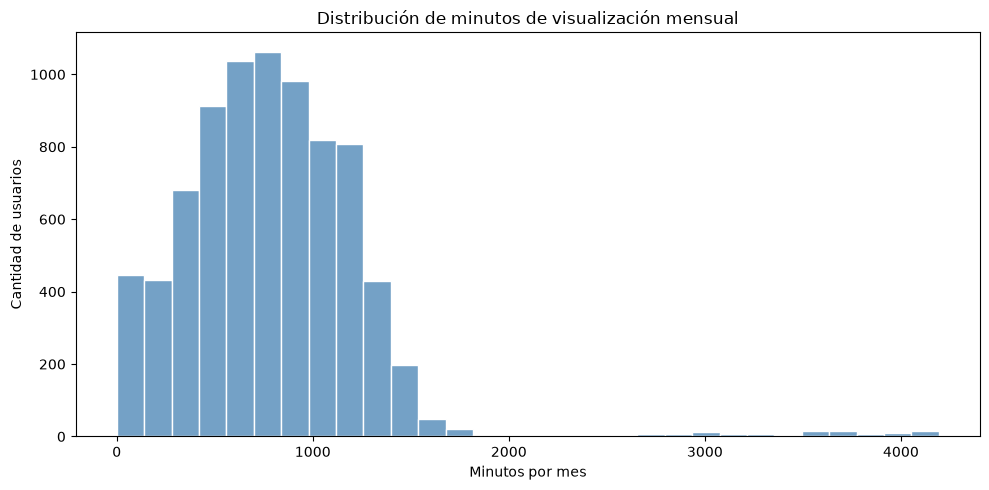

In [27]:
# Distribución de minutos de visualización mensual
plt.figure(figsize=(10, 5))
sns.histplot(df['monthly_watch_time_mins'], bins=30, color='steelblue', edgecolor='white')
plt.title('Distribución de minutos de visualización mensual')
plt.xlabel('Minutos por mes')
plt.ylabel('Cantidad de usuarios')
plt.tight_layout()
plt.show()

**Interpretación:** La distribución de minutos de visualización mensual muestra una asimetría hacia la derecha, con el pico principal alrededor de los 750 minutos y una cola larga hacia valores altos. La mayoría de los usuarios consume entre 250 y 1500 minutos mensuales, mientras que muy pocos superan los 2000 minutos. Esto indica que el consumo típico ronda las 12 horas mensuales, con un segmento pequeño de usuarios con consumo muy elevado. Esta variable será relevante para analizar si los usuarios con mayor consumo coinciden con los que abren más tickets de soporte.

In [28]:
print(f"Media: {df['customer_support_tickets'].mean():.2f}")
print(f"Mediana: {df['customer_support_tickets'].median():.2f}")
print(f"Moda: {df['customer_support_tickets'].mode()[0]:.2f}")
print(f"Desvío estándar: {df['customer_support_tickets'].std():.2f}")
print(f"Mínimo: {df['customer_support_tickets'].min():.2f}")
print(f"Máximo: {df['customer_support_tickets'].max():.2f}")

Media: 0.79
Mediana: 1.00
Moda: 0.00
Desvío estándar: 0.90
Mínimo: 0.00
Máximo: 5.00


**Medidas de customer_support_tickets:** La moda (0) indica que la mayoría de los usuarios no abre tickets de soporte. La mediana (1) y la media (0.79) son muy cercanas, lo que sugiere una distribución bastante simétrica sin valores extremos. El desvío estándar de 0.90 es bajo, confirmando que los valores están concentrados entre 0 y 2 tickets. El máximo de 5 tickets es razonable y coherente con el tratamiento aplicado en la limpieza donde se imputaron los valores mayores a 20.

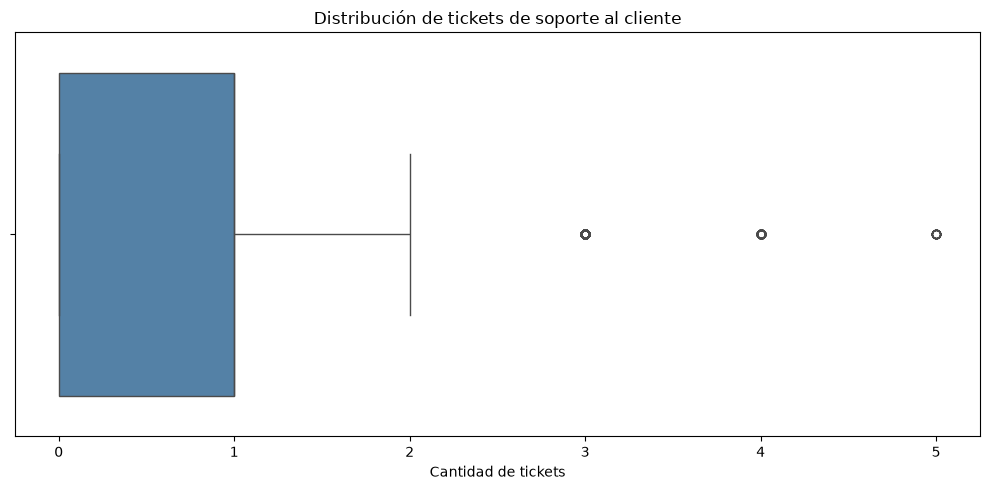

In [29]:
# Distribución de tickets de soporte - Boxplot
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['customer_support_tickets'], color='steelblue')
plt.title('Distribución de tickets de soporte al cliente')
plt.xlabel('Cantidad de tickets')
plt.tight_layout()
plt.show()

**Interpretación:** La distribución de tickets de soporte es asimétrica hacia la derecha, con la gran mayoría de usuarios concentrados en 0 o 1 ticket. A partir de 2 tickets la cantidad cae drásticamente, y el máximo observado es de 5 tickets luego del tratamiento aplicado en la limpieza. Esto indica que la plataforma tiene una baja tasa de problemas técnicos entre sus usuarios, con un segmento muy pequeño que requiere atención recurrente. Esta variable será analizada en relación al consumo mensual y al plan de suscripción en el análisis bivariado.

### Análisis univariado: variables categóricas
Exploración de la distribución de las variables categóricas mediante gráficos de barras.

In [30]:
# Medidas de subscription_plan
print("=== ANÁLISIS UNIVARIADO: subscription_plan ===")
print(f"Valores únicos: {df['subscription_plan'].nunique()}")
print(f"\nDistribución:\n{df['subscription_plan'].value_counts()}")
print(f"\nPorcentaje:\n{df['subscription_plan'].value_counts(normalize=True).mul(100).round(2)}")

=== ANÁLISIS UNIVARIADO: subscription_plan ===
Valores únicos: 3

Distribución:
subscription_plan
Básico      3600
Estándar    2817
Premium     1583
Name: count, dtype: int64

Porcentaje:
subscription_plan
Básico      45.00
Estándar    35.21
Premium     19.79
Name: proportion, dtype: float64


**Medidas de subscription_plan:** El plan Básico es el más frecuente con el 45% de los usuarios, seguido por Estándar con el 35.21% y Premium con el 19.79%. Existe una distribución desigual entre planes, donde casi la mitad de los usuarios opta por el plan más económico. Esto puede estar relacionado con el perfil de edad y país de los usuarios, algo que se explorará en el análisis bivariado.

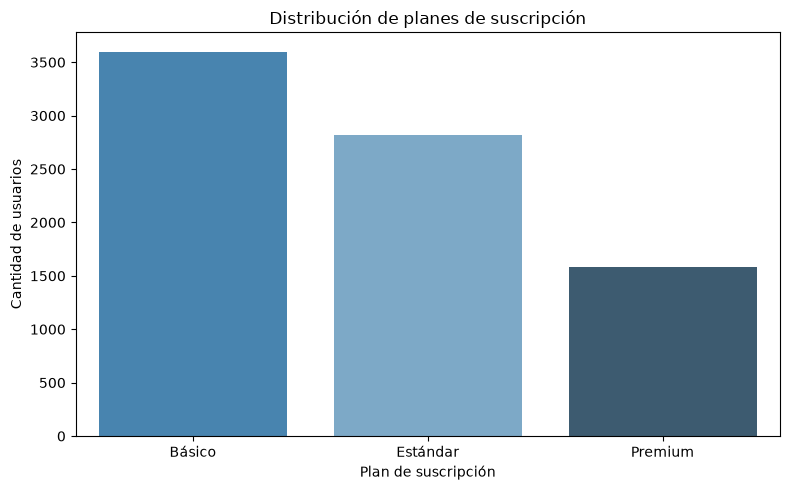

In [31]:
# Distribución de planes de suscripción
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='subscription_plan', hue='subscription_plan', legend=False, palette='Blues_d', order=df['subscription_plan'].value_counts().index)
plt.title('Distribución de planes de suscripción')
plt.xlabel('Plan de suscripción')
plt.ylabel('Cantidad de usuarios')
plt.tight_layout()
plt.show()

**Interpretación:** El gráfico confirma la distribución desigual entre planes. El plan Básico concentra casi la mitad de los usuarios (45%), seguido por Estándar (35%) y Premium (20%). Esta pirámide de suscripción es típica en plataformas de streaming, donde la mayoría de usuarios elige el plan más accesible. Será interesante analizar en el bivariado si esta distribución varía según el país o el rango de edad.

In [32]:
# Medidas de country
print("=== ANÁLISIS UNIVARIADO: country ===")
print(f"Valores únicos: {df['country'].nunique()}")
print(f"\nDistribución:\n{df['country'].value_counts()}")
print(f"\nPorcentaje:\n{df['country'].value_counts(normalize=True).mul(100).round(2)}")

=== ANÁLISIS UNIVARIADO: country ===
Valores únicos: 7

Distribución:
country
Chile        1164
Brasil       1156
México       1156
Uruguay      1143
Colombia     1142
Perú         1134
Argentina    1105
Name: count, dtype: int64

Porcentaje:
country
Chile        14.55
Brasil       14.45
México       14.45
Uruguay      14.29
Colombia     14.27
Perú         14.18
Argentina    13.81
Name: proportion, dtype: float64


**Medidas de country:** Los 7 países tienen una distribución muy equilibrada, todos entre el 13.81% y el 14.55%. Chile lidera levemente con 1164 usuarios y Argentina es el menos representado con 1105. Esta homogeneidad sugiere que el dataset fue construido con una muestra balanceada por país, lo que es favorable para comparaciones en el análisis bivariado.

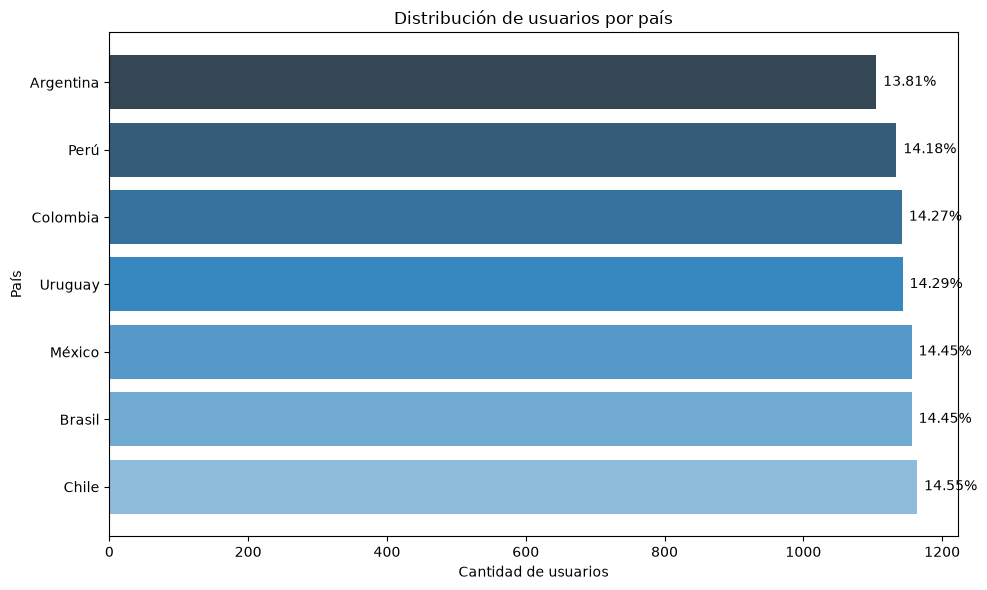

In [33]:
# Distribución de usuarios por país (horizontal con porcentajes)
conteo = df['country'].value_counts()
porcentajes = (conteo / len(df) * 100).round(2)

plt.figure(figsize=(10, 6))
bars = plt.barh(conteo.index, conteo.values, color=sns.color_palette('Blues_d', len(conteo)))

# Agregar porcentajes al final de cada barra
for i, (valor, porcentaje) in enumerate(zip(conteo.values, porcentajes.values)):
    plt.text(valor + 10, i, f'{porcentaje}%', va='center', fontsize=10)

plt.title('Distribución de usuarios por país')
plt.xlabel('Cantidad de usuarios')
plt.ylabel('País')
plt.tight_layout()
plt.show()

**Interpretación:** El gráfico confirma la distribución casi homogénea entre los 7 países. Las barras tienen alturas muy similares, lo que indica que ningún país domina la muestra. Esta uniformidad es una característica del dataset que favorece las comparaciones por país en el análisis bivariado, ya que no hay sesgo por sobrerrepresentación de ningún mercado.

In [34]:
# Medidas de favorite_genre
print("=== ANÁLISIS UNIVARIADO: favorite_genre ===")
print(f"Valores únicos: {df['favorite_genre'].nunique()}")
print(f"\nDistribución:\n{df['favorite_genre'].value_counts()}")
print(f"\nPorcentaje:\n{df['favorite_genre'].value_counts(normalize=True).mul(100).round(2)}")

=== ANÁLISIS UNIVARIADO: favorite_genre ===
Valores únicos: 8

Distribución:
favorite_genre
Comedia        1138
Drama          1115
Romance        1110
Documental     1107
Thriller       1104
Acción         1104
Crimen         1085
Desconocido     237
Name: count, dtype: int64

Porcentaje:
favorite_genre
Comedia        14.22
Drama          13.94
Romance        13.88
Documental     13.84
Thriller       13.80
Acción         13.80
Crimen         13.56
Desconocido     2.96
Name: proportion, dtype: float64


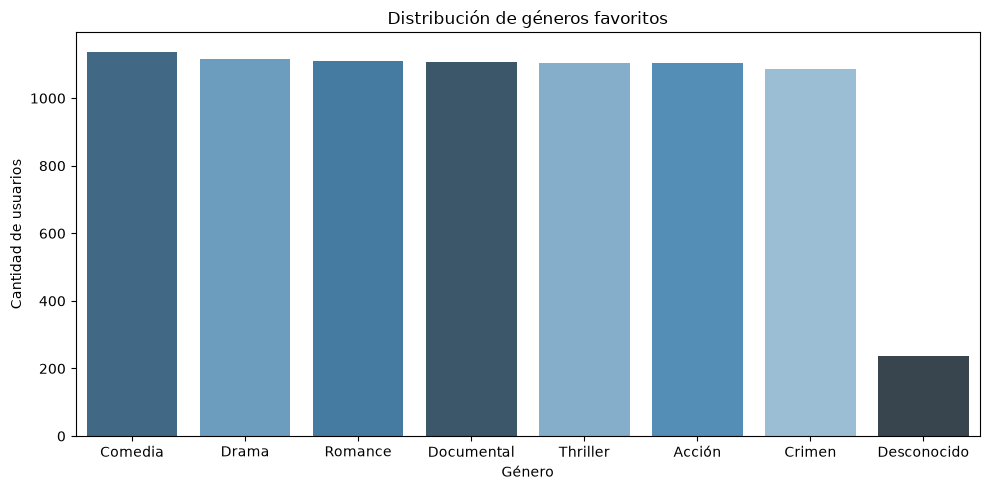

In [35]:
# Distribución de géneros favoritos
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='favorite_genre', hue='favorite_genre', legend=False,
              palette='Blues_d', order=df['favorite_genre'].value_counts().index)
plt.title('Distribución de géneros favoritos')
plt.xlabel('Género')
plt.ylabel('Cantidad de usuarios')
plt.tight_layout()
plt.show()

**Interpretación:** La distribución de géneros es bastante equilibrada entre las 7 categorías válidas, 
con Comedia liderando levemente (14.23%) y Crimen como el menos frecuente (13.56%). 
El valor 'Desconocido' representa el 2.96% de los usuarios (237 casos imputados en la etapa de limpieza), 
lo que es un porcentaje bajo y no distorsiona el análisis. Esta homogeneidad sugiere que las preferencias 
de género están distribuidas de forma uniforme en la plataforma, sin un género dominante claro.

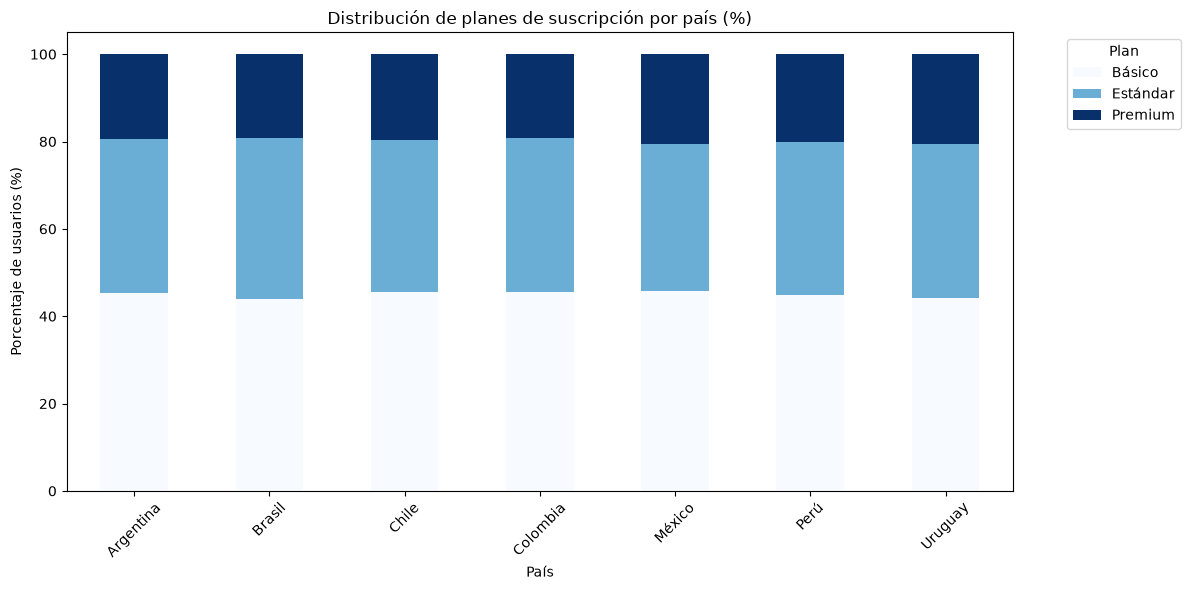

In [36]:
# Bivariada 1: Distribución de planes de suscripción por país
tabla_planes_pais = df.groupby(['country', 'subscription_plan']).size().unstack(fill_value=0)
tabla_planes_pais_pct = tabla_planes_pais.div(tabla_planes_pais.sum(axis=1), axis=0).mul(100)

tabla_planes_pais_pct.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='Blues')
plt.title('Distribución de planes de suscripción por país (%)')
plt.xlabel('País')
plt.ylabel('Porcentaje de usuarios (%)')
plt.legend(title='Plan', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Interpretación:** El gráfico muestra que la distribución de planes de suscripción es 
relativamente homogénea entre los 7 países, sin diferencias marcadas entre mercados. 
En todos los países el plan Básico es el más frecuente, seguido por Estándar y Premium. 
Esto sugiere que la preferencia por el plan más económico no está determinada por el país 
de origen del usuario, sino posiblemente por otros factores como la edad o el consumo mensual.

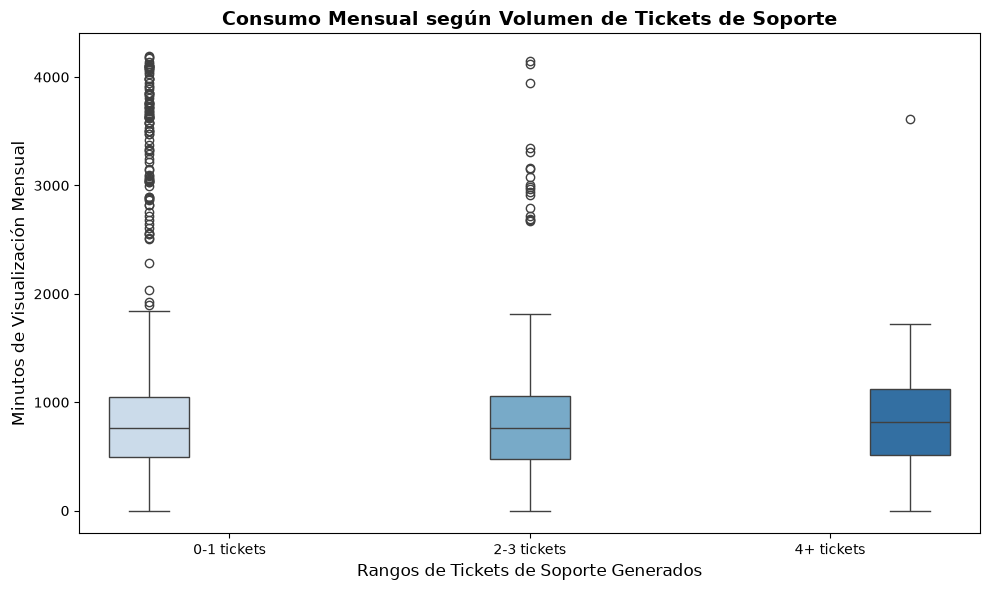

In [37]:
# --- BIVARIADA 2: CONSUMO MENSUAL SEGÚN RANGO DE TICKETS DE SOPORTE ---

# Evaluamos dinámicamente el valor máximo real del dataset
max_tickets = df['customer_support_tickets'].max()

# Definimos los cortes de forma adaptativa según el techo de tus datos
if max_tickets <= 3:
    bins = [-1, 0, 1, max_tickets]
    etiquetas = ['0 tickets', '1 ticket', '2+ tickets']
elif max_tickets <= 6:
    bins = [-1, 1, 3, max_tickets]
    etiquetas = ['0-1 tickets', '2-3 tickets', '4+ tickets']
else:
    bins = [-1, 1, 3, 6, max_tickets]
    etiquetas = ['0-1 tickets', '2-3 tickets', '4-6 tickets', '7+ tickets']

# Creamos la columna categórica por rangos de forma segura
df['rango_tickets'] = pd.cut(
    df['customer_support_tickets'], 
    bins=bins, 
    labels=etiquetas
)

# Construcción de la visualización
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df, 
    x='rango_tickets', 
    y='monthly_watch_time_mins',
    hue='rango_tickets', 
    palette='Blues', 
    legend=False
)

plt.title('Consumo Mensual según Volumen de Tickets de Soporte', fontsize=14, fontweight='bold')
plt.xlabel('Rangos de Tickets de Soporte Generados', fontsize=12)
plt.ylabel('Minutos de Visualización Mensual', fontsize=12)
plt.tight_layout()
plt.show()

# Eliminamos la columna auxiliar para conservar las 8 columnas originales
df = df.drop(columns=['rango_tickets'])

**Interpretación:** Los boxplots muestran que la mediana de consumo mensual es similar 
entre los distintos rangos de tickets, lo que sugiere que el volumen de visualización 
no está directamente relacionado con la cantidad de tickets abiertos. Los usuarios con 
más tickets (7+) no muestran un consumo significativamente mayor o menor al resto. 
Esto indica que los problemas con el soporte podrían estar asociados a otros factores 
como el plan de suscripción o el país, más que al nivel de consumo.

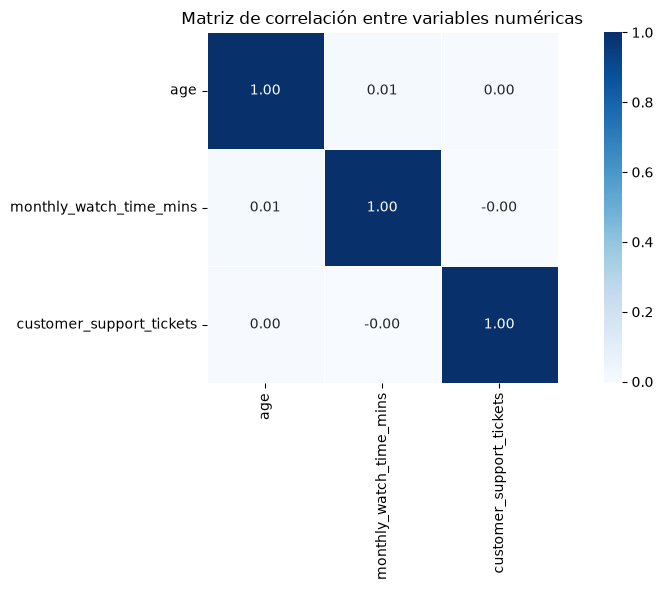

In [38]:
# Análisis multivariado - Heatmap de correlación
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

correlacion = df[['age', 'monthly_watch_time_mins', 'customer_support_tickets']].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(correlacion, annot=True, fmt='.2f', cmap='Blues', 
            linewidths=0.5, square=True)
plt.title('Matriz de correlación entre variables numéricas')
plt.tight_layout()
plt.show()

**Interpretación:** La matriz de correlación muestra que las tres variables numéricas del dataset — edad, minutos de consumo mensual y tickets de soporte — son prácticamente independientes entre sí. Ninguna correlación supera el 0.01 en valor absoluto, lo que indica que consumir más contenido no implica abrir más tickets, ni que la edad determina el nivel de consumo. Esto sugiere que el comportamiento de los usuarios en esta plataforma no responde a patrones lineales simples entre estas variables.

## Conclusiones generales del EDA

El análisis exploratorio permitió responder las preguntas planteadas en la inspección inicial y caracterizar el comportamiento de los usuarios de la plataforma.

**Sobre el perfil del usuario:**
El usuario típico es un adulto de entre 25 y 45 años, con una mediana de 35 años, que consume alrededor de 750 minutos mensuales y abre entre 0 y 1 tickets de soporte. La distribución es equilibrada entre los 7 países y los 3 planes de suscripción.

**Sobre las relaciones entre variables:**
No se encontraron correlaciones significativas entre las variables numéricas. El consumo mensual no determina la cantidad de tickets, ni la edad define el plan elegido o el género favorito. El heatmap de correlación confirmó que todas las correlaciones son menores a 0.02 en valor absoluto.

**Sobre la distribución geográfica y comercial:**
La distribución por país es homogénea, sin mercados dominantes. El plan Básico concentra el 45% de los usuarios en todos los países, lo que sugiere que el precio es el principal factor de decisión independientemente del origen geográfico.

**Implicancias para el PCA:**
La ausencia de correlaciones entre variables anticipa que el PCA tendrá una capacidad de reducción de dimensionalidad limitada, ya que PCA aprovecha mejor los datasets donde las variables están correlacionadas. Esto se confirmará en el Notebook 04.